# 02 — Participants overview

This notebook is the demographic and survey-metadata companion to [`01_prompts_overview.ipynb`](01_prompts_overview.ipynb). It tours `data/metadata/participants.csv`: one row per participant, covering everything we collected about them that **is not audio** — self-reported demographics, linguistic background, recording setup, voice-assistant usage, and a handful of audit-design bookkeeping flags.

All demographic data is **self-reported** via a Qualtrics survey, recruited through Prolific. Participant IDs (`P0001` … `P0515`) are anonymized and match the per-participant audio folders under `data/audio/{cohort}/{participant_id}/`.

The aim here is the same as the prompts notebook: give a reader a fast, faithful sense of *what is in the file* without pre-empting any downstream analysis. We do not yet stratify outputs, compute model-bias metrics, or filter by audit eligibility — that comes in later notebooks.

**Inputs:** `../data/metadata/participants.csv`  
**Outputs:** none written to disk.

## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent
PARTICIPANTS_CSV = REPO_ROOT / "data" / "metadata" / "participants.csv"

participants = pd.read_csv(PARTICIPANTS_CSV)
print(f"Loaded {len(participants)} participants from {PARTICIPANTS_CSV.relative_to(REPO_ROOT)}")
participants.head(3)

## 1. Schema

There are 34 columns. They fall naturally into seven groups:

**Identity / cohort**
- `participant_id` — anonymized ID (`P0001`+), matches the folder name under `data/audio/{cohort}/`.
- `cohort` — `new_recruits` vs. `reconsent`. Two waves of data collection driven purely by logistics; the survey instrument and audio protocol were identical across waves.

**Audit-design columns (derived)**
- `race_simplified`, `gender_simplified` — the two derived columns that map self-report into the Black/White × Female/Male audit grid (see § 2).
- `audit_eligible` — boolean; participant fits the 4-cell Black/White × Female/Male design at all.
- `strict_audit_eligible` — boolean; the stricter subset where Prolific-recruitment cell agrees with self-report.
- `prolific_recruitment_group` — the cell we recruited the participant under on Prolific (`bl_fe`, `bl_ma`, `wh_fe`, `wh_ma`). Each cell was its own Prolific study, identical in every way except the demographic filter.
- `prolific_filter_matches_self_report` — boolean; `False` when the Prolific filter and the participant's self-report disagree. We don't know whether disagreements are honest reclassifications or filter slippage, so we keep these participants in the data and define a stricter `strict_audit_eligible` fold that excludes them.

**Survey demographics (binned)**
- `age_bin`, `income_bin`, `education`
- `gender_self_report`, `race_self_report_raw`, `race_other_text`

**Linguistic background**
- `english_proficiency`, `english_accent_self_report`, `english_accent_other_text`
- `primary_language`, `primary_language_other_text`, `languages_fluent`, `languages_fluent_other_text`

**Geography**
- `residency_state`, `residency_other_text`
- `country_childhood`, `country_childhood_other_text`, `state_childhood`

**Recording / voice-assistant context**
- `recording_device`, `recording_device_other_text`, `device_brand_model_text`
- `frequency_voice_assistant`, `frequency_text_assistant`, `ux_voice`, `voice_underperform_text`

**Survey-completion**
- `duration_s` — total Qualtrics session duration in seconds.

Most binned columns include an `"Other (Please specify)"` option that routes free-text into a paired `*_text` column.

In [2]:
print("Shape:", participants.shape)
print("\nFree-text columns (mostly NaN by design):")
text_cols = [c for c in participants.columns if c.endswith("_text")]
pd.DataFrame({
    "populated": [participants[c].notna().sum() for c in text_cols],
    "missing":   [participants[c].isna().sum() for c in text_cols],
}, index=text_cols)

Shape: (515, 34)

Free-text columns (mostly NaN by design):


,populated,missing
race_other_text,1,514
english_accent_other_text,24,491
primary_language_other_text,11,504
languages_fluent_other_text,11,504
residency_other_text,0,515
country_childhood_other_text,19,496
recording_device_other_text,4,511
device_brand_model_text,510,5
voice_underperform_text,493,22


## 2. Cohort

The two cohorts (`new_recruits`, `reconsent`) differ only in *when* they completed the survey. We surface the column so analyses can stratify, but they are otherwise interchangeable.

In [3]:
participants["cohort"].value_counts().rename_axis("cohort").to_frame("n_participants")

,n_participants
cohort,
reconsent,266
new_recruits,249


## 3. Derived audit columns: `race_simplified`, `gender_simplified`

The primary audit is defined over a **Black/White × Female/Male** recruitment grid. The raw self-report columns (`race_self_report_raw`, `gender_self_report`) contain multi-select responses that don't map directly into the grid, so we derive two collapsed labels.

**Rules used to derive `race_simplified` from `race_self_report_raw`:**

1. If the participant selected `Black or African American` (alone or in combination with anything else) → **Black**. For audit purposes, mixed Black-and-other responses are grouped with Black responses. This follows a hypodescent-informed U.S. sociology convention, though it should not be read as a claim about respondents’ self-identification or as the default federal demographic standard.
2. Otherwise, if the participant selected `White or European American` (alone or with non-Black categories, including with `Hispanic or Latino`) → **White**.
3. Otherwise → **Other/Unknown**. These participants are kept in the dataset for parts of the study outside the 2×2 audit, but are flagged out of the primary audit by `audit_eligible=False`.

**Rules used to derive `gender_simplified` from `gender_self_report`:**

- `Man` → **Male**
- `Woman` → **Female**
- `Non-binary` (or anything else) → kept as-is in `gender_simplified`, flagged out of the primary audit.

These rules are deterministic and reproducible from `race_self_report_raw` + `gender_self_report` alone.

In [4]:
race_gender_table = (
    participants.groupby(["race_simplified", "gender_simplified"]).size().unstack(fill_value=0)
)
race_gender_table["total"] = race_gender_table.sum(axis=1)
race_gender_table.loc["total"] = race_gender_table.sum(axis=0)
race_gender_table

gender_simplified,Female,Male,Non-binary,total
race_simplified,,,,
Black,124,127,3,254
Other/Unknown,1,3,0,4
White,128,127,2,257
total,253,257,5,515


In [5]:
print("All race_self_report_raw response combinations (raw, multi-select), with derived race_simplified:")
raw_to_simplified = (
    participants.groupby(["race_self_report_raw", "race_simplified"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
raw_to_simplified

All race_self_report_raw response combinations (raw, multi-select), with derived race_simplified:


,race_self_report_raw,race_simplified,n
13,White or European American,White,242
2,Black or African American,Black,234
3,"Black or African American,Hispanic or Latino",Black,8
8,Hispanic or Latino,White,7
10,"Hispanic or Latino,White or European American",White,6
4,"Black or African American,Native American or A...",Black,5
11,I prefer not to answer,Other/Unknown,4
6,"Black or African American,White or European Am...",Black,3
0,"Asian or Asian American,Black or African American",Black,1
1,"Asian or Asian American,Black or African Ameri...",Black,1


## 4. Audit eligibility flags

- `audit_eligible` — participant has `race_simplified ∈ {Black, White}` **and** `gender_simplified ∈ {Male, Female}`. This is the broad audit fold.
- `strict_audit_eligible` — additionally requires `prolific_filter_matches_self_report=True`. This is the conservative fold used for primary analyses.

Differences between the two folds isolate the participants whose Prolific-filter cell disagreed with their Qualtrics self-report — we don't know whether those discrepancies are filter slippage or genuine reclassification, so we report both folds.

In [6]:
eligibility = pd.DataFrame({
    "audit_eligible": participants["audit_eligible"].value_counts(),
    "strict_audit_eligible": participants["strict_audit_eligible"].value_counts(),
    "prolific_filter_matches_self_report": participants["prolific_filter_matches_self_report"].value_counts(),
}).fillna(0).astype(int)
eligibility

,audit_eligible,strict_audit_eligible,prolific_filter_matches_self_report
True,506,500,500
False,9,15,15


## 5. Prolific recruitment grid

Each of the four recruitment cells (`bl_fe`, `bl_ma`, `wh_fe`, `wh_ma`) was a separate Prolific study with the corresponding demographic filter set on Prolific. The counts are roughly balanced by design.

In [7]:
participants["prolific_recruitment_group"].value_counts().rename_axis("prolific_recruitment_group").to_frame("n_participants")

,n_participants
prolific_recruitment_group,
bl_fe,132
wh_fe,128
bl_ma,128
wh_ma,127


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [8]:
print("Prolific recruitment cell vs. self-reported (race_simplified, gender_simplified):")
prolific_vs_self = (
    participants.groupby(["prolific_recruitment_group", "race_simplified", "gender_simplified"])
    .size()
    .rename("n")
    .reset_index()
    .pivot_table(
        index="prolific_recruitment_group",
        columns=["race_simplified", "gender_simplified"],
        values="n",
        fill_value=0,
    )
)
prolific_vs_self

Prolific recruitment cell vs. self-reported (race_simplified, gender_simplified):


race_simplified             Black                   Other/Unknown       White  \
gender_simplified          Female   Male Non-binary        Female Male Female   
prolific_recruitment_group                                                      
bl_fe                       124.0    3.0        2.0           1.0  0.0    2.0   
bl_ma                         0.0  124.0        1.0           0.0  3.0    0.0   
wh_fe                         0.0    0.0        0.0           0.0  0.0  126.0   
wh_ma                         0.0    0.0        0.0           0.0  0.0    0.0   

race_simplified                               
gender_simplified            Male Non-binary  
prolific_recruitment_group                    
bl_fe                         0.0        0.0  
bl_ma                         0.0        0.0  
wh_fe                         1.0        1.0  
wh_ma                       126.0        1.0

## 6. Survey demographics: age, income, education

Each of these is a Qualtrics single-select with predefined bins (so the categories are fixed; the counts are what differ). `"I prefer not to answer"` appears as a valid bin for income.

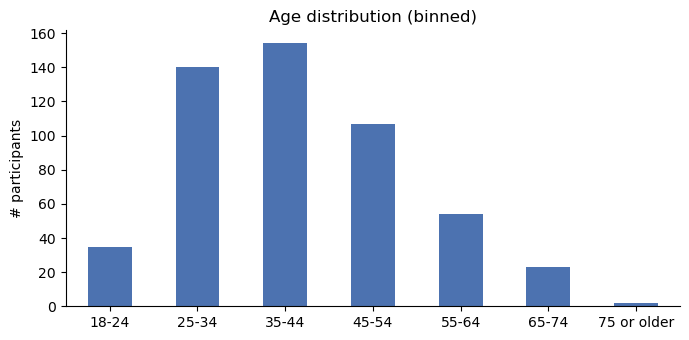

,n_participants
age_bin,
18-24,35
25-34,140
35-44,154
45-54,107
55-64,54
65-74,23
75 or older,2


In [9]:
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75 or older"]
age_counts = participants["age_bin"].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(7, 3.5))
age_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("")
ax.set_ylabel("# participants")
ax.set_title("Age distribution (binned)")
plt.xticks(rotation=0)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
age_counts.to_frame("n_participants")

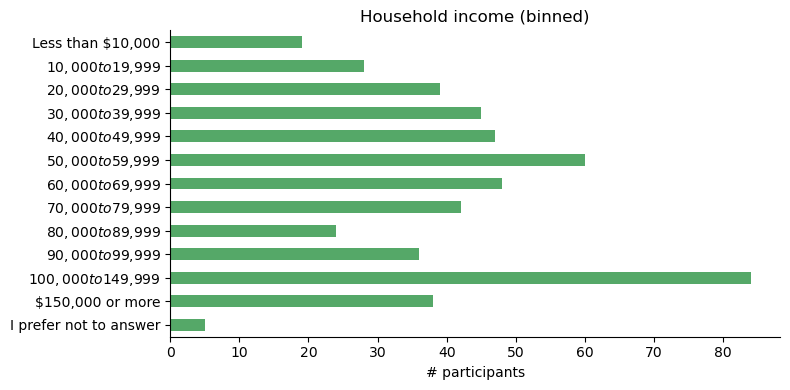

In [10]:
income_order = [
    "Less than $10,000", "$10,000 to $19,999", "$20,000 to $29,999",
    "$30,000 to $39,999", "$40,000 to $49,999", "$50,000 to $59,999",
    "$60,000 to $69,999", "$70,000 to $79,999", "$80,000 to $89,999",
    "$90,000 to $99,999", "$100,000 to $149,999", "$150,000 or more",
    "I prefer not to answer",
]
income_counts = participants["income_bin"].value_counts().reindex(income_order)

fig, ax = plt.subplots(figsize=(8, 4))
income_counts.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("# participants")
ax.set_ylabel("")
ax.set_title("Household income (binned)")
ax.invert_yaxis()
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
education_order = [
    "Less than high school degree",
    "High school graduate (high school diploma or equivalent including GED)",
    "Some college but no degree",
    "Associate degree in college (2-year)",
    "Bachelor's degree in college (4-year)",
    "Master's degree",
    "Professional degree (JD, MD)",
    "Doctoral degree",
]
participants["education"].value_counts().reindex(education_order).to_frame("n_participants")

,n_participants
education,
Less than high school degree,6
High school graduate (high school diploma or equivalent including GED),88
Some college but no degree,106
Associate degree in college (2-year),50
Bachelor's degree in college (4-year),181
Master's degree,64
"Professional degree (JD, MD)",8
Doctoral degree,12


## 7. Linguistic background

We collected English proficiency, perceived accent, primary language, and a multi-select of languages the participant is fluent in. The accent and languages columns are multi-select (Qualtrics joins selected options with commas), so the raw value counts include co-occurrence combinations rather than unique categories — that is intentional and we leave it un-flattened here so the reader can see the rawness of the field.

In [12]:
participants["english_proficiency"].value_counts().rename_axis("english_proficiency").to_frame("n_participants")

,n_participants
english_proficiency,
I speak English fluently as a first language,495
I speak English fluently as a second or additional language,20


In [13]:
print("Top 10 english_accent_self_report values (multi-select, raw combinations):")
participants["english_accent_self_report"].value_counts().head(10).to_frame("n_participants")

Top 10 english_accent_self_report values (multi-select, raw combinations):


,n_participants
english_accent_self_report,
Standard American English,154
African American English,99
Southern accent,36
"African American English,Standard American English",33
Midland or Northern Midwest accent,26
California accent,21
Mid Atlantic accent,17
New England accent,16
"African American English,Southern accent",14


In [14]:
print("Top 10 primary_language values:")
participants["primary_language"].value_counts().head(10).to_frame("n_participants")

Top 10 primary_language values:


,n_participants
primary_language,
English,482
Other,11
French,3
"English,Spanish",3
"English,French",3
"English,Polish",2
"English,German",2
"English,Russian",2
Spanish,1


In [15]:
print("Top 10 languages_fluent values (multi-select, raw combinations):")
participants["languages_fluent"].value_counts().head(10).to_frame("n_participants")

Top 10 languages_fluent values (multi-select, raw combinations):


,n_participants
languages_fluent,
English,449
"English,Spanish",15
Spanish,9
"English,French",8
"English,Other",4
Other,3
French,3
"English,Polish",2
"English,Portuguese",2


## 8. Geography

All participants are US residents (Prolific filter). `country_childhood` captures the country they grew up in (a small minority are non-US childhood); `residency_state` is current state of residence.

In [16]:
participants["country_childhood"].value_counts().to_frame("n_participants")

,n_participants
country_childhood,
United States,496
Other (Please specify),17
"United States,Other (Please specify)",2


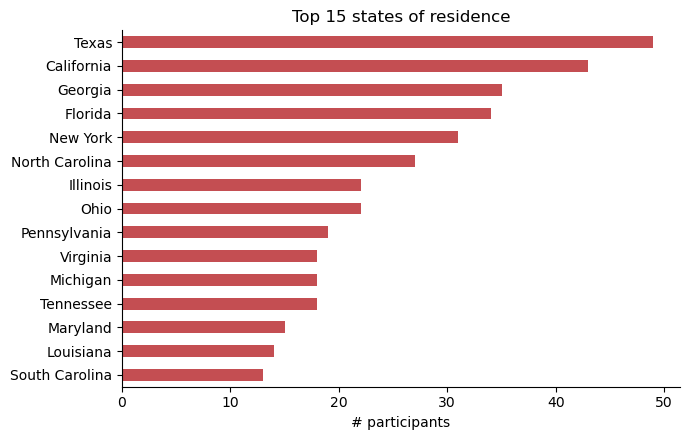

45 distinct states of residence


In [17]:
top_states = participants["residency_state"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(7, 4.5))
top_states.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("# participants")
ax.set_ylabel("")
ax.set_title("Top 15 states of residence")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
print(f"{participants['residency_state'].nunique()} distinct states of residence")

## 9. Recording context and voice-assistant familiarity

These columns describe *how* the audio was captured (device class + free-text brand/model) and the participant's reported relationship with voice/text assistants. They're useful as covariates: differences in recording device or user familiarity can confound model-output differences that look demographic.

In [18]:
participants["recording_device"].value_counts().to_frame("n_participants")

,n_participants
recording_device,
Laptop/Computer with built-in microphone,225
Smartphone,152
Laptop/Computer with external microphone,120
Tablet,14
Other (Please specify),4


In [19]:
freq_order = [
    "Daily or more",
    "At least once per week, but not every day",
    "At least once per month, but not every week",
    "Only a few times",
    "Not at all",
]
freq_table = pd.DataFrame({
    "frequency_voice_assistant": participants["frequency_voice_assistant"].value_counts().reindex(freq_order),
    "frequency_text_assistant":  participants["frequency_text_assistant"].value_counts().reindex(freq_order),
})
freq_table

,frequency_voice_assistant,frequency_text_assistant
Daily or more,171,217
"At least once per week, but not every day",180,186
"At least once per month, but not every week",46,49
Only a few times,77,43
Not at all,41,20


In [20]:
ux_order = ["Not well at all", "Slightly well", "Moderately well", "Very well", "Extremely well"]
participants["ux_voice"].value_counts().reindex(ux_order).to_frame(
    "n_participants — 'How well do voice assistants understand you?'"
)

,n_participants — 'How well do voice assistants understand you?'
ux_voice,
Not well at all,11
Slightly well,46
Moderately well,170
Very well,211
Extremely well,77


## 10. Survey duration

`duration_s` is the total Qualtrics session length in seconds. A few outliers (sessions left idle in a browser tab) inflate the tail, so the median is the more reliable summary.

Session duration in minutes:
count    515.0
mean      30.6
std       20.4
min        8.8
25%       20.4
50%       26.7
75%       36.8
max      391.2
Name: duration_s, dtype: float64


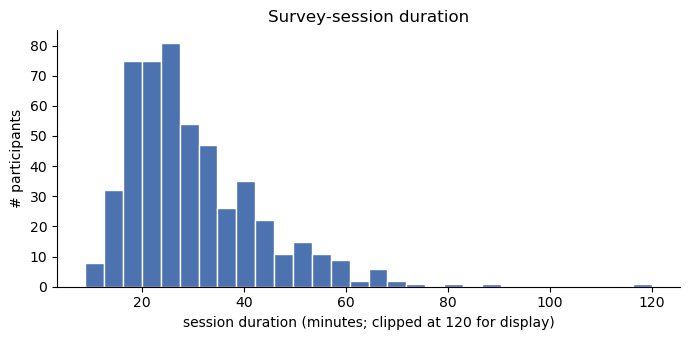

In [21]:
minutes = participants["duration_s"] / 60.0
print("Session duration in minutes:")
print(minutes.describe().round(1))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(minutes.clip(upper=120), bins=30, color="#4C72B0", edgecolor="white")
ax.set_xlabel("session duration (minutes; clipped at 120 for display)")
ax.set_ylabel("# participants")
ax.set_title("Survey-session duration")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Free-form text columns

Several columns are paired free-text follow-ups (`*_other_text`) or open-ended prompts (`voice_underperform_text`, `device_brand_model_text`). They are sparsely populated by design — only filled when the participant picked `"Other"` on the corresponding closed question. We do not analyze these here, but we surface a few example values so a reader knows what kind of strings to expect.

In [ ]:
sample_text_cols = ["device_brand_model_text", "voice_underperform_text", "languages_fluent_other_text"]
for c in sample_text_cols:
    n_filled = participants[c].notna().sum()
    print(f"--- {c} ({n_filled} populated / {len(participants)}) ---")
    examples = (
        participants[c].dropna().astype(str).sample(min(3, n_filled), random_state=0).tolist()
    )
    for ex in examples:
        ex_short = ex if len(ex) <= 200 else ex[:200] + " […]"
        print(f"  • {ex_short}")
    print()

## Summary

- **515 participants** in two cohorts (`new_recruits`=249, `reconsent`=266), interchangeable for analysis.
- The Black/White × Female/Male audit grid contains **500 strict-eligible** and **506 broadly eligible** participants; the rest are kept for non-audit analyses.
- Self-report multi-select fields (`race_self_report_raw`, `english_accent_self_report`, `languages_fluent`, `primary_language`) are stored as raw comma-joined Qualtrics strings; the derived `race_simplified` / `gender_simplified` columns collapse race+gender into the audit grid via the rules described in § 3.
- Binned demographics (age, income, education) span the full survey range; participants are concentrated in the 25–54 age bands and across the U.S., with no single state dominant.
- Recording device, voice-assistant frequency, and `ux_voice` are available as potential covariates.
- Free-text columns are sparse (only filled when the participant picked `"Other"` or the open-ended follow-up was triggered).